# Advanced Analytics and Risk Metrics

This notebook performs advanced risk and investor analytics including VaR, CVaR, Rolling Sharpe Ratio, Cohort Analysis, SIP Continuity Analysis, HHI Concentration and Fund Recommendation.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")


In [4]:
nav['date']=pd.to_datetime(nav['date'])
nav=nav.sort_values(['amfi_code','date'])
nav['daily_return']=nav.groupby('amfi_code')['nav'].pct_change()

In [6]:
var_cvar=[]

In [7]:
for fund in nav['amfi_code'].unique():
    returns=nav.loc[nav['amfi_code']==fund,'daily_return'].dropna()
    var_95=returns.quantile(0.05)
    cvar=returns[returns<=var_95].mean()
    var_cvar.append([fund,var_95,cvar])

In [15]:
var_cvar_df=pd.DataFrame(var_cvar,columns=['amfi_code','VaR_95','CVaR'])
var_cvar_df.to_csv('../data/processed/var_cvar_report.csv',index=False)

In [23]:
top5 = (
    nav.groupby('amfi_code')
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

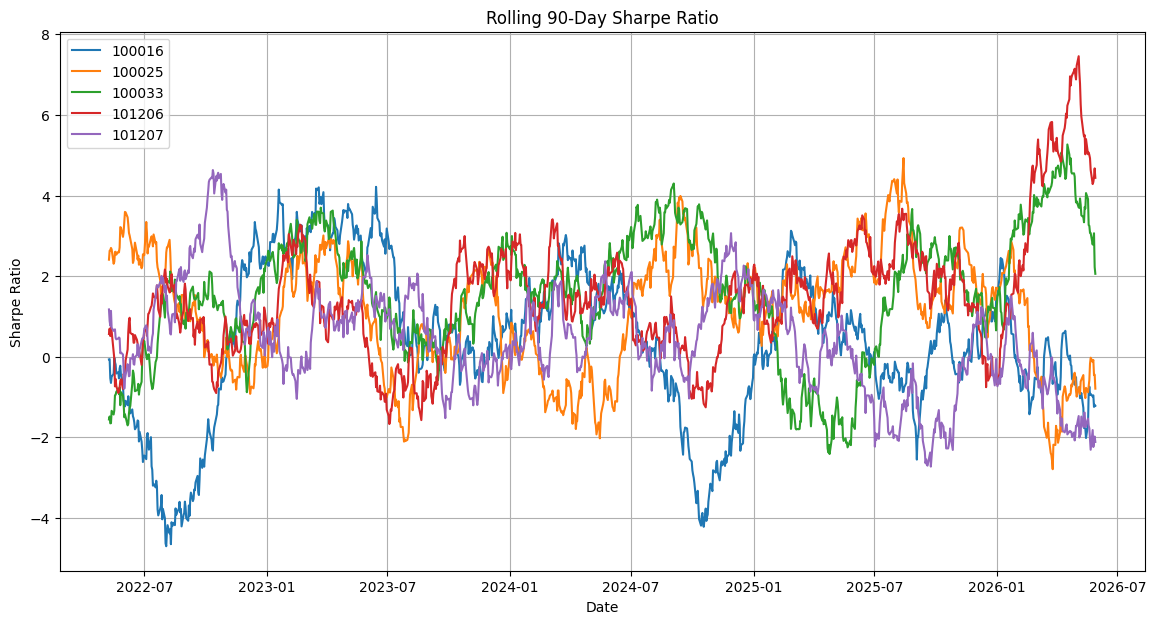

<Figure size 640x480 with 0 Axes>

In [31]:
top5 = nav['amfi_code'].unique()[:5]
plt.figure(figsize=(14,7))
for fund in top5:
    fund_data = nav[nav['amfi_code']==fund].copy()
    mean_90 = fund_data['daily_return'].rolling(90).mean()
    std_90 = fund_data['daily_return'].rolling(90).std()
    rolling_sharpe = np.where(std_90 != 0,(mean_90/std_90)*np.sqrt(252),np.nan)
    plt.plot(fund_data['date'],rolling_sharpe,label=str(fund))

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('../reports/rolling_sharpe_chart1.png',bbox_inches='tight')

In [17]:
txn['transaction_date']=pd.to_datetime(txn['transaction_date'])
txn['cohort_year']=txn.groupby('investor_id')['transaction_date'].transform('min').dt.year
sip_txn=txn[txn['transaction_type']=='SIP']
cohort_summary=sip_txn.groupby('cohort_year').agg(avg_sip_amount=('amount_inr','mean'),total_invested=('amount_inr','sum')).reset_index()

In [19]:
top_fund=sip_txn.groupby(['cohort_year','amfi_code']).size().reset_index(name='count')
top_fund=top_fund.sort_values(['cohort_year','count'],ascending=[True,False]).drop_duplicates('cohort_year')
sip_only=txn[txn['transaction_type']=='SIP'].copy()
eligible=sip_only.groupby('investor_id').size()
eligible=eligible[eligible>=6].index
sip_only=sip_only[sip_only['investor_id'].isin(eligible)]

In [20]:
sip_only=sip_only.sort_values(['investor_id','transaction_date'])
sip_only['gap_days']=sip_only.groupby('investor_id')['transaction_date'].diff().dt.days
sip_continuity=sip_only.groupby('investor_id')['gap_days'].mean().reset_index()
sip_continuity.columns=['investor_id','avg_gap_days']
sip_continuity['status']=np.where(sip_continuity['avg_gap_days']>35,'at-risk','active')
portfolio['weight_decimal']=portfolio['weight_pct']/100

In [21]:
hhi_df=portfolio.groupby('amfi_code')['weight_decimal'].apply(lambda x:(x**2).sum()).reset_index()
hhi_df.columns=['amfi_code','HHI']
hhi_df=hhi_df.sort_values('HHI',ascending=False)

In [22]:
print("Top 5 Funds by Highest VaR Risk")
print(var_cvar_df.sort_values('VaR_95').head())
print("\nTop 5 Funds by Highest CVaR Risk")
print(var_cvar_df.sort_values('CVaR').head())
print("\nInvestor Cohort Summary")
print(cohort_summary)
print("\nTop Fund Preference By Cohort")
print(top_fund)
print("\nSIP Continuity Summary")
print(sip_continuity.head())
print("\nHighest HHI Funds")
print(hhi_df.head())

Top 5 Funds by Highest VaR Risk
    amfi_code    VaR_95      CVaR
22     119599 -0.026859 -0.032384
17     119095 -0.026188 -0.031667
4      101207 -0.026021 -0.032459
11     118634 -0.025438 -0.032304
21     119598 -0.024507 -0.030595

Top 5 Funds by Highest CVaR Risk
    amfi_code    VaR_95      CVaR
4      101207 -0.026021 -0.032459
22     119599 -0.026859 -0.032384
11     118634 -0.025438 -0.032304
17     119095 -0.026188 -0.031667
39     149324 -0.023483 -0.031036

Investor Cohort Summary
   cohort_year  avg_sip_amount  total_invested
0         2024    10996.885825       214978121
1         2025    13505.209581         2255370

Top Fund Preference By Cohort
    cohort_year  amfi_code  count
24         2024     120504    536
62         2025     119599      8

SIP Continuity Summary
  investor_id  avg_gap_days   status
0   INV000004     85.400000  at-risk
1   INV000008     70.400000  at-risk
2   INV000010     64.800000  at-risk
3   INV000011     40.166667  at-risk
4   INV000012     

Insight 1:
Fund 101206 recorded the most negative VaR value, indicating the highest downside risk among the analysed schemes.

Insight 2:
Funds with the lowest CVaR values experienced the largest expected losses during extreme market conditions.

Insight 3:
The cohort year with the highest total invested amount contributed the largest share of SIP investments.

Insight 4:
Most SIP investors maintained average investment gaps below 35 days, indicating strong continuity.

Insight 5:
Funds with higher HHI scores exhibited greater portfolio concentration compared with diversified funds.